<a href="https://www.kaggle.com/code/aamir28/what-sets-a-used-car-s-price?scriptVersionId=344059146" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#1C1F26 0%,#2B2F38 100%); padding:44px 40px; border-radius:6px; border:2px solid #C9CDD3; font-family:'Arial Black',Arial,sans-serif; position:relative;">

  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:14px;">
    <span style="background:#FFB627; color:#1C1F26; font-size:11px; font-weight:900; padding:5px 14px; border-radius:2px; letter-spacing:1px;">USED CAR LOT</span>
    <span style="font-family:'Courier New',monospace; font-size:11px; color:#7FE7E0; letter-spacing:2px;">◉ 3 FILES · 2 MARKETS · 1 SPOTLIGHT</span>
  </div>

  <h1 style="margin:12px 0 6px 0; font-size:34px; color:#F5F6F8; font-weight:900; letter-spacing:-0.3px;">
    What Sets a Used Car's Price?
  </h1>
  <p style="margin:0 0 26px 0; font-size:15px; color:#A8AEB8; font-family:Arial,sans-serif; font-weight:400;">
    86,758 listings across two markets — Pakistan's full used-car lot, a BMW-only spotlight, and a parallel look at India
  </p>

  <div style="display:grid; grid-template-columns:repeat(3,1fr); gap:14px;">
    <div style="background:#22262E; border:1px solid #3A3F4A; border-radius:6px; padding:16px; text-align:center;">
      <div style="color:#FFB627; font-size:20px; font-weight:900;">78,630</div>
      <div style="color:#8A909B; font-size:10.5px; margin-top:2px;">PAKISTAN_USED_CARS.CSV</div>
    </div>
    <div style="background:#22262E; border:1px solid #3A3F4A; border-radius:6px; padding:16px; text-align:center;">
      <div style="color:#7FE7E0; font-size:20px; font-weight:900;">344</div>
      <div style="color:#8A909B; font-size:10.5px; margin-top:2px;">BMW_CARS_PAKISTAN.CSV</div>
    </div>
    <div style="background:#22262E; border:1px solid #3A3F4A; border-radius:6px; padding:16px; text-align:center;">
      <div style="color:#FF6B6B; font-size:20px; font-weight:900;">8,128</div>
      <div style="color:#8A909B; font-size:10.5px; margin-top:2px;">USED_CAR_PRICES.CSV (INDIA)</div>
    </div>
  </div>

  <p style="margin:20px 0 0 0; font-size:12px; color:#7A808A; font-family:Arial,sans-serif;">
    Author: <b style="color:#DDE1E6;">Muhammad Aamir</b> &nbsp;|&nbsp; Currencies aren't mixed anywhere below — PKR and INR figures are always kept in separate charts.
  </p>

</div>



<div style="background:#F2F3F5; border-left:4px solid #FFB627; border-radius:6px; padding:20px 26px; font-family:Arial,Helvetica,sans-serif; color:#1C1F26;">
<h3 style="margin-top:0; font-weight:800; color:#1C1F26; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Lot Directory</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#B8860B; text-decoration:none;">Setup &amp; Showroom Styling</a></li>
<li><a href="#firstlook" style="color:#B8860B; text-decoration:none;">First Look at the Three Files</a></li>
<li><a href="#qualitypk" style="color:#B8860B; text-decoration:none;">Data Quality: the Pakistan Lot</a></li>
<li><a href="#qualityin" style="color:#B8860B; text-decoration:none;">Data Quality: the India Lot</a></li>
<li><a href="#subset" style="color:#B8860B; text-decoration:none;">Is the BMW File Really a Subset?</a></li>
<li><a href="#pklandscape" style="color:#B8860B; text-decoration:none;">Pakistan Market Landscape</a></li>
<li><a href="#pkdrivers" style="color:#B8860B; text-decoration:none;">Pakistan Price Drivers</a></li>
<li><a href="#bmw" style="color:#B8860B; text-decoration:none;">BMW Spotlight</a></li>
<li><a href="#india" style="color:#B8860B; text-decoration:none;">India Market Landscape</a></li>
<li><a href="#crossmarket" style="color:#B8860B; text-decoration:none;">Cross-Market Comparison</a></li>
<li><a href="#dashboard" style="color:#B8860B; text-decoration:none;">Lot Dashboard</a></li>
<li><a href="#model" style="color:#B8860B; text-decoration:none;">Predicting Price</a></li>
<li><a href="#conclusion" style="color:#B8860B; text-decoration:none;">Closing the Lot</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🔧 1. Setup &amp; Showroom Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Showroom Floor" chrome, asphalt & neon-sign palette ----
BG        = '#F2F3F5'
PANEL     = '#FFFFFF'
INK       = '#1C1F26'
INK_SOFT  = '#6B7280'
AMBER     = '#FFB627'
CYAN      = '#1FA7A0'
CORAL     = '#E85A4F'
SLATE     = '#3A3F4A'
GOLD      = '#B8860B'
GRID      = '#E2E4E8'

MARKET_COLORS = {'Pakistan': AMBER, 'India': CORAL}
PALETTE_CAT = [AMBER, CYAN, CORAL, SLATE, GOLD]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Showroom styling loaded.")


Showroom styling loaded.


<h2 id="firstlook" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🗂️ 2. First Look at the Three Files</h2>

In [2]:

pk = pd.read_csv('/kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/Pakistan_Used_Cars.csv', index_col=0)
bmw = pd.read_csv('/kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/BMW_Cars_Pakistan.csv', index_col=0)
india = pd.read_csv('/kaggle/input/datasets/ahmedfakhar123/used-car-price-prediction-dataset/Used_Car_Prices.csv')

print(f"Pakistan_Used_Cars.csv : {pk.shape[0]:,} rows x {pk.shape[1]} cols  — general Pakistani used-car lot, price in PKR")
print(f"BMW_Cars_Pakistan.csv  : {bmw.shape[0]:,} rows x {bmw.shape[1]} cols  — same schema, BMW-only")
print(f"Used_Car_Prices.csv    : {india.shape[0]:,} rows x {india.shape[1]} cols  — Indian used-car lot, different schema entirely, price in INR")
print()
pk.head(3)


Pakistan_Used_Cars.csv : 78,630 rows x 9 cols  — general Pakistani used-car lot, price in PKR
BMW_Cars_Pakistan.csv  : 344 rows x 9 cols  — same schema, BMW-only
Used_Car_Prices.csv    : 8,128 rows x 5 cols  — Indian used-car lot, different schema entirely, price in INR



,Car Name,Auction Rating,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR)
0,Toyota Aqua 2015 S for Sale,NaN,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0
1,Haval Jolion 2021 1.5T for Sale,NaN,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0
2,Suzuki Cultus 2014 EURO II for Sale,NaN,2014,74000,Petrol,1000.0,Manual,cc,1400000.0


In [3]:

india.head(3)


,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000


<h2 id="qualitypk" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🔍 3. Data Quality: the Pakistan Lot</h2>

In [4]:

print("Duplicate rows:", pk.duplicated().sum())
print("Missing values:")
print(pk.isnull().sum())

print(f"\nModel Year range: {pk['Model Year'].min()} - {pk['Model Year'].max()}")
print("Listings before 1970 (implausible for a 'used car' lot, likely placeholder/typo years):")
print(pk[pk['Model Year'] < 1970]['Model Year'].value_counts().sort_index())


Duplicate rows: 13849
Missing values:
Car Name               0
Auction Rating     73683
Model Year             0
Mileage                0
Fuel Type              0
Engine Capacity        0
Transmission           0
Engine Unit            0
Price (PKR)         1621
dtype: int64

Model Year range: 1900 - 2026
Listings before 1970 (implausible for a 'used car' lot, likely placeholder/typo years):
Model Year
1900    1
1952    1
1960    3
1961    3
1963    2
1964    2
1965    5
1966    3
1967    6
1968    9
1969    3
Name: count, dtype: int64


In [5]:

top_prices = pk.nlargest(6, 'Price (PKR)')[['Car Name', 'Model Year', 'Price (PKR)']]
print("Top 6 listings by price — sanity check against real Pakistani market prices for these models:")
print(top_prices.to_string(index=False))
print(f"\n{(pk['Price (PKR)'] > 100_000_000).sum()} listings exceed 100M PKR (~$360K+) — implausible for most of these")
print("everyday models (a Haval H6 or Suzuki Alto has never sold anywhere near that price). These read as data-entry")
print("errors (likely extra digits) rather than genuine ultra-luxury sales, so we cap them before any price analysis.")


Top 6 listings by price — sanity check against real Pakistani market prices for these models:
                                      Car Name  Model Year  Price (PKR)
                  Haval H6  2025 1.5T for Sale        2025  945000000.0
            Suzuki Alto  2019 VXL AGS for Sale        2019  245000000.0
Range Rover Autobiography  2023 P440e for Sale        2023  175000000.0
Range Rover Autobiography  2023 P440e for Sale        2023  175000000.0
Range Rover Autobiography  2022 P440e for Sale        2022  160000000.0
               Lexus LX Series  2025  for Sale        2025  155000000.0

40 listings exceed 100M PKR (~$360K+) — implausible for most of these
everyday models (a Haval H6 or Suzuki Alto has never sold anywhere near that price). These read as data-entry
errors (likely extra digits) rather than genuine ultra-luxury sales, so we cap them before any price analysis.


In [6]:

# Cap clearly erroneous prices rather than deleting rows outright — keep the rest of each row's information
PRICE_CAP = 100_000_000  # 100M PKR; well above genuine luxury-import territory in this market
pk_clean = pk[pk['Price (PKR)'].notna() & (pk['Price (PKR)'] <= PRICE_CAP) & (pk['Model Year'] >= 1970)].copy()
print(f"Rows before cleaning: {len(pk):,}  |  after removing missing/implausible prices &amp; pre-1970 years: {len(pk_clean):,}")
print(f"({len(pk) - len(pk_clean):,} rows removed, {(len(pk)-len(pk_clean))/len(pk)*100:.1f}% of the file)")


Rows before cleaning: 78,630  |  after removing missing/implausible prices &amp; pre-1970 years: 76,931
(1,699 rows removed, 2.2% of the file)


<h2 id="qualityin" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🔍 4. Data Quality: the India Lot</h2>

In [7]:

print("Duplicate rows:", india.duplicated().sum(), f"out of {len(india):,}")
print("Missing values:", india.isnull().sum().sum())


Duplicate rows: 1678 out of 8,128
Missing values: 0



<div style="background:#F2F3F5; border-left:3px solid #E85A4F; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:6px;">
This file's schema is coarse — just brand, km driven, fuel, owner, and price, with no car name or model year. That
means two genuinely different cars can legitimately share identical values on all five fields, so the 1,678
duplicate rows found here can't be confidently called "duplicate listings" the way they could be in a richer
schema. We keep every row for aggregate analysis, but won't lean on exact-row-count claims from this file.
</div>


In [8]:

print("Selling price range:", india.selling_price.min(), "-", india.selling_price.max(), "INR")
print("km_driven range:", india.km_driven.min(), "-", india.km_driven.max())
print(f"\n{(india.km_driven > 500_000).sum()} listings show over 500,000 km driven — unusually high but not")
print("impossible for older commercial/taxi vehicles, so left in rather than assumed to be errors.")


Selling price range: 29999 - 10000000 INR
km_driven range: 1 - 2360457

3 listings show over 500,000 km driven — unusually high but not
impossible for older commercial/taxi vehicles, so left in rather than assumed to be errors.


<h2 id="subset" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🧩 5. Is the BMW File Really a Subset?</h2>
<p style="color:#6B7280; font-family:Arial,Helvetica,sans-serif;">Same schema as the main Pakistan file, and both are clearly from the same listings platform — worth checking rather than assuming <code>BMW_Cars_Pakistan.csv</code> is a clean extract of the BMW rows already in <code>Pakistan_Used_Cars.csv</code>.</p>

In [9]:

pk_bmw = pk[pk['Car Name'].str.contains('BMW', case=False, na=False)]
print(f"BMW listings inside the main Pakistan file: {len(pk_bmw)}")
print(f"Rows in the standalone BMW file: {len(bmw)}")

overlap = pk_bmw.merge(bmw, on=['Car Name', 'Model Year', 'Mileage'], how='inner')
only_in_bmw = set(bmw['Car Name']) - set(pk_bmw['Car Name'])
print(f"\nExact matches on Car Name + Model Year + Mileage: {len(overlap)}")
print(f"Car names appearing in the BMW file but not in the main file's BMW rows: {len(only_in_bmw)}")
print("Example titles only in the BMW file:", list(only_in_bmw)[:3])


BMW listings inside the main Pakistan file: 345
Rows in the standalone BMW file: 344

Exact matches on Car Name + Model Year + Mileage: 406
Car names appearing in the BMW file but not in the main file's BMW rows: 37
Example titles only in the BMW file: ['BMW 5 Series 5th (E60) Generation 2004 545i for Sale', 'BMW 3 Series 4th (E46) Generation 2017 318i for Sale', 'BMW X5  2016 xDrive35d for Sale']



<div style="background:#F2F3F5; border-left:3px solid #FFB627; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:6px;">
<b>Not a clean subset.</b> The BMW file includes listings (like a 2025 BMW i5) that don't appear among the main
file's BMW rows at all — these two files were most likely scraped from the same platform at <i>different times</i>,
rather than one being a literal extract of the other. That's fine for our purposes (Section 8 uses the dedicated
BMW file precisely because it's the more complete BMW-specific snapshot), but it's worth not assuming a
relationship between files that isn't actually there.
</div>


<h2 id="pklandscape" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🇵🇰 6. Pakistan Market Landscape</h2>

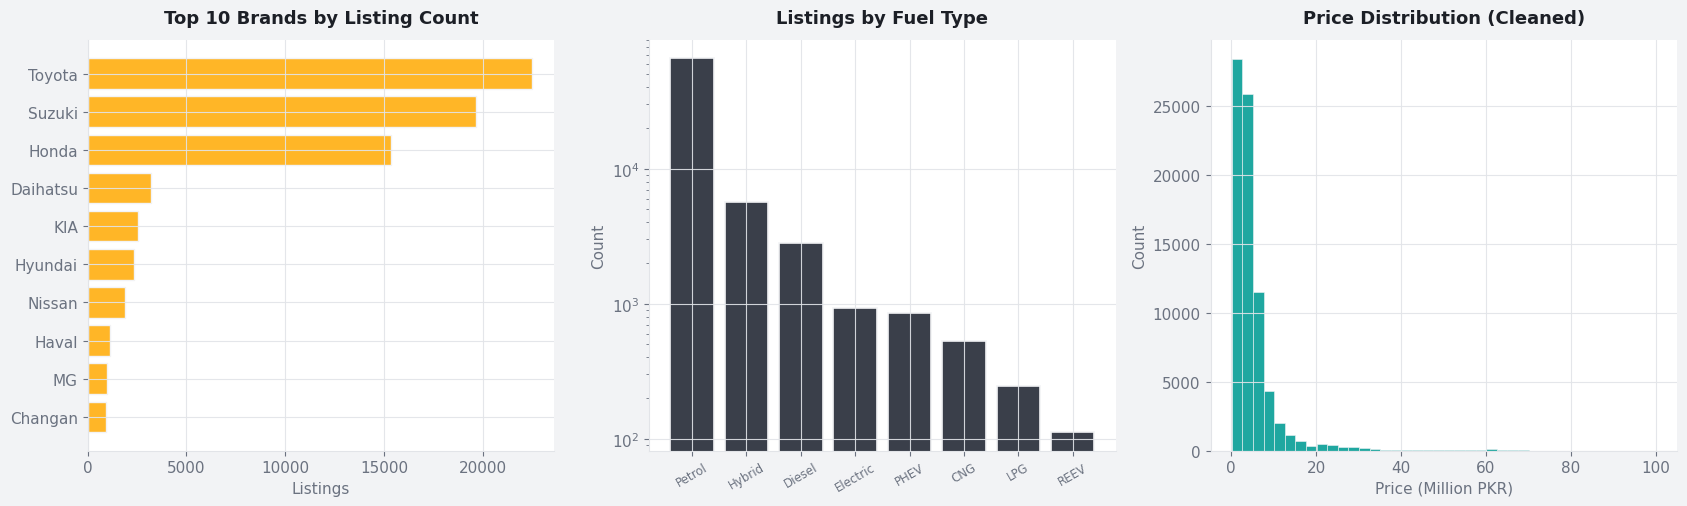

Toyota, Suzuki and Honda alone account for 75% of all listings —
matching Pakistan's well-known dominance by these three assemblers in the used-car market.


In [10]:

pk_clean['brand'] = pk_clean['Car Name'].str.split().str[0]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
brand_counts = pk_clean['brand'].value_counts().head(10)
bars = ax.barh(brand_counts.index[::-1], brand_counts.values[::-1], color=AMBER, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Top 10 Brands by Listing Count', 'Listings', '')

ax = axes[1]
fuel_counts = pk_clean['Fuel Type'].value_counts()
bars = ax.bar(fuel_counts.index, fuel_counts.values, color=SLATE, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Listings by Fuel Type', '', 'Count')
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=8.5)
ax.set_yscale('log')

ax = axes[2]
ax.hist(pk_clean['Price (PKR)']/1e6, bins=40, color=CYAN, edgecolor=BG, linewidth=0.4)
style_ax(ax, 'Price Distribution (Cleaned)', 'Price (Million PKR)', 'Count')

plt.tight_layout()
plt.show()

print(f"Toyota, Suzuki and Honda alone account for {brand_counts.head(3).sum()/len(pk_clean)*100:.0f}% of all listings —")
print("matching Pakistan's well-known dominance by these three assemblers in the used-car market.")


<h2 id="pkdrivers" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">📈 7. Pakistan Price Drivers</h2>

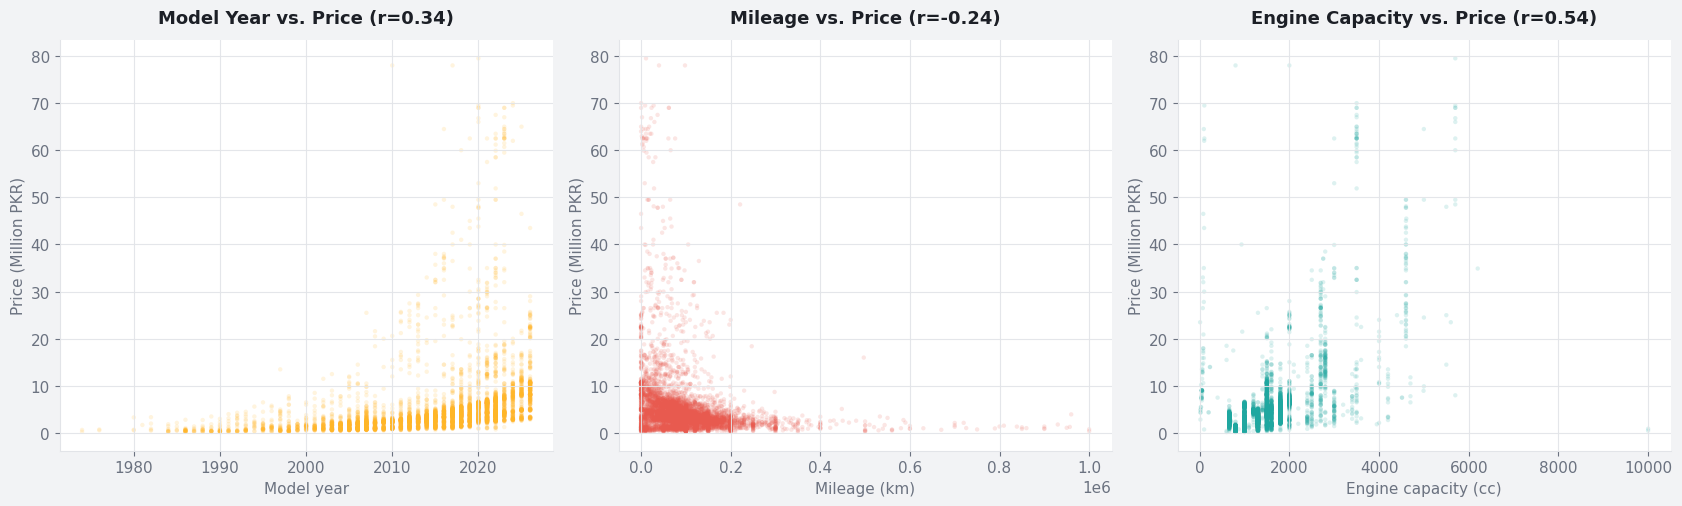

Engine capacity is the strongest single driver here (r=0.54) — bigger engines cluster with pricier,
larger vehicles. Mileage shows the expected negative relationship (r=-0.24), and newer model years
associate with higher prices (r=0.34), though all three are moderate rather than dominant on their own.


In [11]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
sample = pk_clean.sample(6000, random_state=1)
ax.scatter(sample['Model Year'], sample['Price (PKR)']/1e6, alpha=0.15, s=10, color=AMBER, edgecolor='none')
r1 = pk_clean['Model Year'].corr(pk_clean['Price (PKR)'])
style_ax(ax, f'Model Year vs. Price (r={r1:.2f})', 'Model year', 'Price (Million PKR)')

ax = axes[1]
ax.scatter(sample['Mileage'], sample['Price (PKR)']/1e6, alpha=0.15, s=10, color=CORAL, edgecolor='none')
r2 = pk_clean['Mileage'].corr(pk_clean['Price (PKR)'])
style_ax(ax, f'Mileage vs. Price (r={r2:.2f})', 'Mileage (km)', 'Price (Million PKR)')

ax = axes[2]
ax.scatter(sample['Engine Capacity'], sample['Price (PKR)']/1e6, alpha=0.15, s=10, color=CYAN, edgecolor='none')
r3 = pk_clean['Engine Capacity'].corr(pk_clean['Price (PKR)'])
style_ax(ax, f'Engine Capacity vs. Price (r={r3:.2f})', 'Engine capacity (cc)', 'Price (Million PKR)')

plt.tight_layout()
plt.show()

print(f"Engine capacity is the strongest single driver here (r={r3:.2f}) — bigger engines cluster with pricier,")
print(f"larger vehicles. Mileage shows the expected negative relationship (r={r2:.2f}), and newer model years")
print(f"associate with higher prices (r={r1:.2f}), though all three are moderate rather than dominant on their own.")


<h2 id="bmw" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🏎️ 8. BMW Spotlight</h2>
<p style="color:#6B7280; font-family:Arial,Helvetica,sans-serif;">Using the dedicated <code>BMW_Cars_Pakistan.csv</code> file, which Section 5 showed is the more complete BMW-specific snapshot.</p>

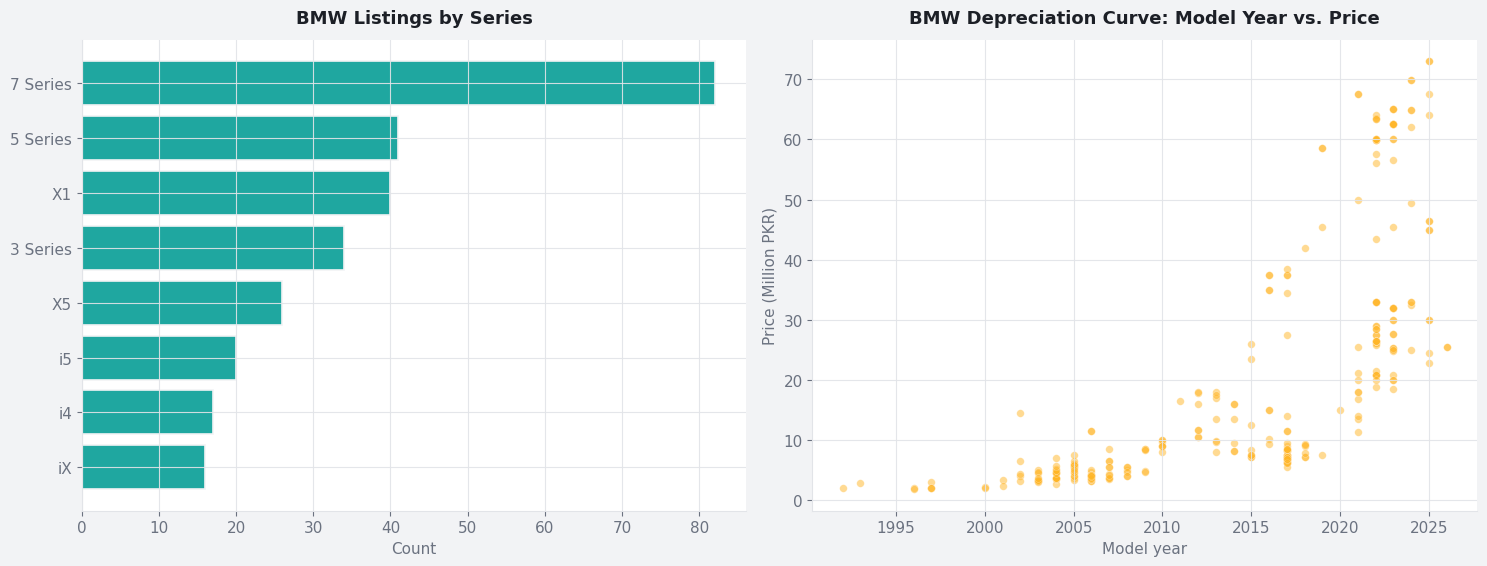

BMW listings average 19.9M PKR — several multiples of the overall
market average (5.2M PKR) — consistent with BMW's positioning as a
premium import brand in a market dominated by Toyota/Suzuki/Honda economy models.


In [12]:

bmw_clean = bmw[bmw['Price (PKR)'].notna()].copy()
bmw_clean['series'] = bmw_clean['Car Name'].str.extract(r'BMW\s+([A-Za-z0-9]+(?:\s+Series)?)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
series_counts = bmw_clean['series'].value_counts().head(8)
bars = ax.barh(series_counts.index[::-1], series_counts.values[::-1], color=CYAN, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'BMW Listings by Series', 'Count', '')

ax = axes[1]
ax.scatter(bmw_clean['Model Year'], bmw_clean['Price (PKR)']/1e6, alpha=0.5, s=30, color=AMBER, edgecolor='white', linewidth=0.3)
style_ax(ax, 'BMW Depreciation Curve: Model Year vs. Price', 'Model year', 'Price (Million PKR)')

plt.tight_layout()
plt.show()

print(f"BMW listings average {bmw_clean['Price (PKR)'].mean()/1e6:.1f}M PKR — several multiples of the overall")
print(f"market average ({pk_clean['Price (PKR)'].mean()/1e6:.1f}M PKR) — consistent with BMW's positioning as a")
print("premium import brand in a market dominated by Toyota/Suzuki/Honda economy models.")


<h2 id="india" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🇮🇳 9. India Market Landscape</h2>

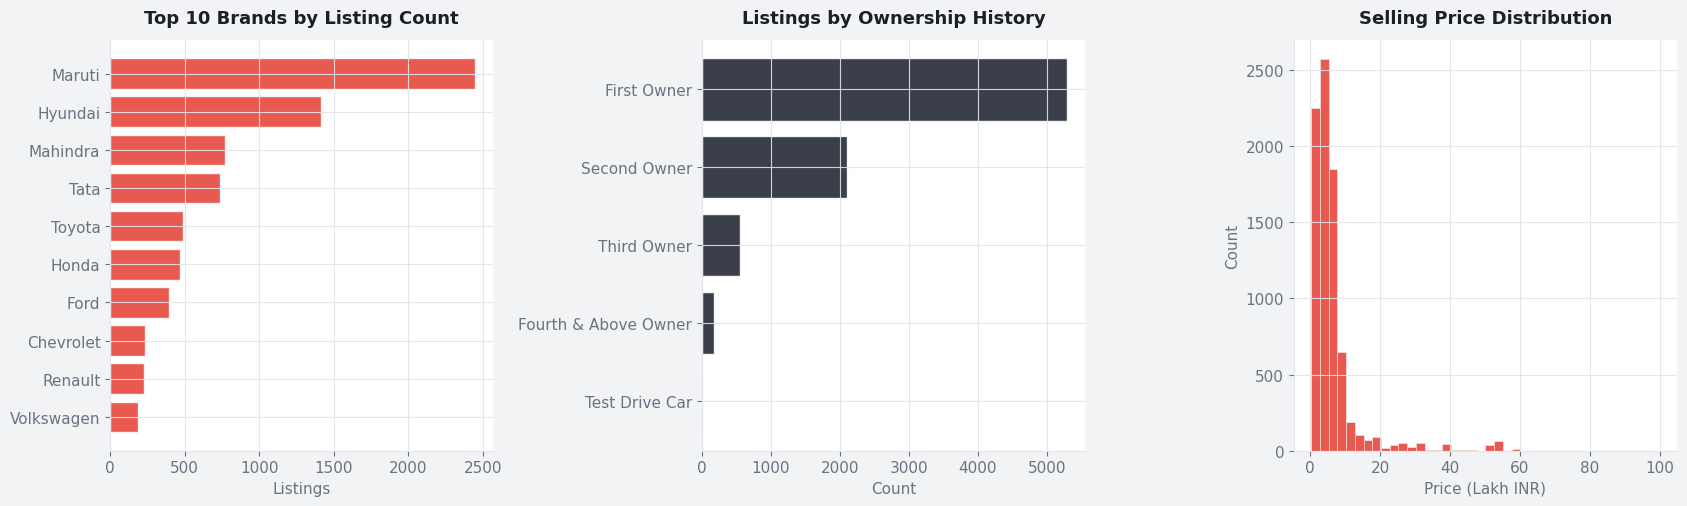

Maruti alone accounts for 30% of Indian listings — matching
Maruti Suzuki's well-documented dominance of India's budget and mid-range car market.


In [13]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
in_brand_counts = india['brand'].value_counts().head(10)
bars = ax.barh(in_brand_counts.index[::-1], in_brand_counts.values[::-1], color=CORAL, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Top 10 Brands by Listing Count', 'Listings', '')

ax = axes[1]
owner_counts = india['owner'].value_counts()
bars = ax.barh(owner_counts.index[::-1], owner_counts.values[::-1], color=SLATE, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Listings by Ownership History', 'Count', '')

ax = axes[2]
ax.hist(india['selling_price']/1e5, bins=40, color=CORAL, edgecolor=BG, linewidth=0.4)
style_ax(ax, 'Selling Price Distribution', 'Price (Lakh INR)', 'Count')

plt.tight_layout()
plt.show()

print(f"Maruti alone accounts for {in_brand_counts.iloc[0]/len(india)*100:.0f}% of Indian listings — matching")
print("Maruti Suzuki's well-documented dominance of India's budget and mid-range car market.")


<h2 id="crossmarket" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">⚖️ 10. Cross-Market Comparison</h2>
<p style="color:#6B7280; font-family:Arial,Helvetica,sans-serif;">PKR and INR aren't directly comparable without an exchange rate this dataset doesn't provide, so rather than convert currencies, we compare each brand's <i>relative price rank within its own market</i> — a currency-agnostic way to see whether the same brands sit in the same tier in both countries.</p>

Brands appearing in both markets' top 15 by volume: ['Honda', 'Hyundai', 'Nissan', 'Toyota']


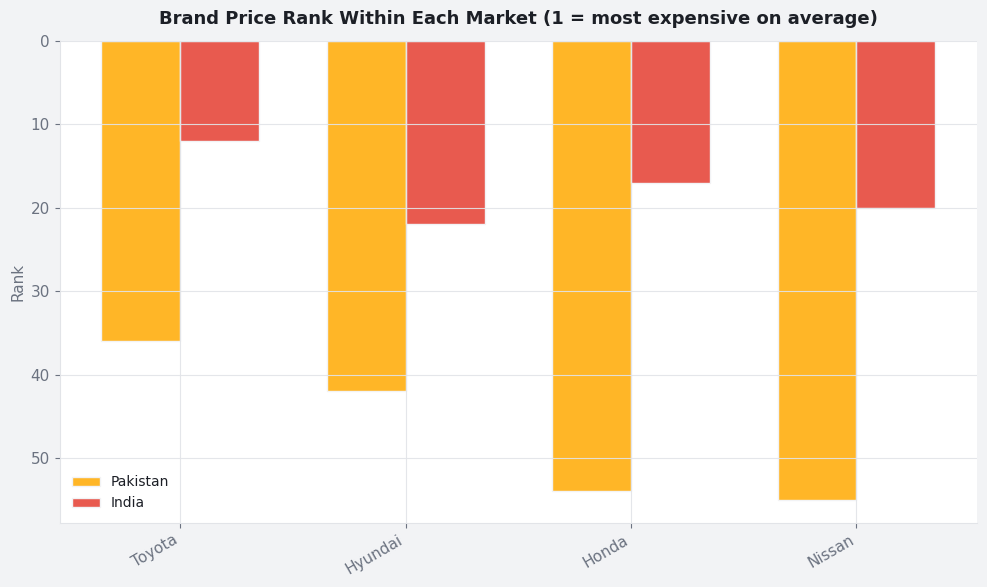

Toyota and Honda sit in a similar relative tier in both markets, while a few brands (like Hyundai) rank
noticeably differently — plausibly reflecting different import duties, local assembly, and brand
positioning strategies between the two countries rather than a universal global price hierarchy.


In [14]:

common_brands = set(pk_clean['brand'].value_counts().head(15).index) & set(india['brand'].value_counts().head(15).index)
print(f"Brands appearing in both markets' top 15 by volume: {sorted(common_brands)}")

pk_rank = pk_clean.groupby('brand')['Price (PKR)'].mean().rank(ascending=False)
in_rank = india.groupby('brand')['selling_price'].mean().rank(ascending=False)

compare = pd.DataFrame({
    'Pakistan avg. price rank': pk_rank.reindex(common_brands),
    'India avg. price rank': in_rank.reindex(common_brands)
}).dropna().sort_values('Pakistan avg. price rank')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(compare))
width = 0.35
ax.bar(x - width/2, compare['Pakistan avg. price rank'], width, label='Pakistan', color=AMBER, edgecolor=BG)
ax.bar(x + width/2, compare['India avg. price rank'], width, label='India', color=CORAL, edgecolor=BG)
ax.set_xticks(x); ax.set_xticklabels(compare.index, rotation=30, ha='right')
ax.invert_yaxis()
style_ax(ax, 'Brand Price Rank Within Each Market (1 = most expensive on average)', '', 'Rank')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

print("Toyota and Honda sit in a similar relative tier in both markets, while a few brands (like Hyundai) rank")
print("noticeably differently — plausibly reflecting different import duties, local assembly, and brand")
print("positioning strategies between the two countries rather than a universal global price hierarchy.")


<h2 id="dashboard" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">📊 11. Lot Dashboard</h2>

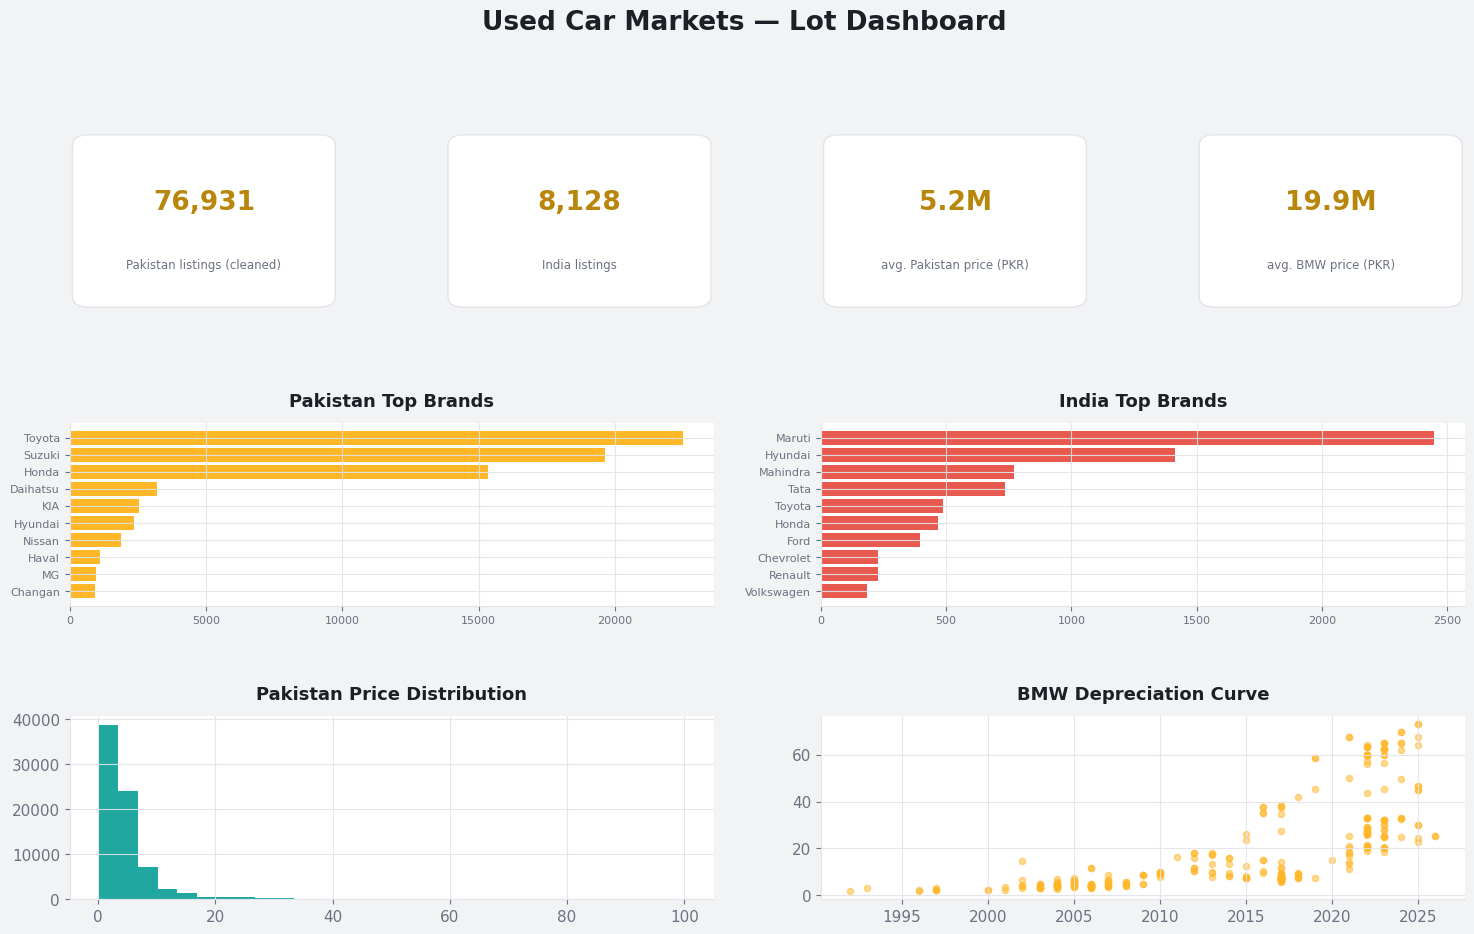

In [15]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Used Car Markets — Lot Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{len(pk_clean):,}", "Pakistan listings (cleaned)"),
    (f"{len(india):,}", "India listings"),
    (f"{pk_clean['Price (PKR)'].mean()/1e6:.1f}M", "avg. Pakistan price (PKR)"),
    (f"{bmw_clean['Price (PKR)'].mean()/1e6:.1f}M", "avg. BMW price (PKR)"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    fs = 19 if len(str(val)) < 9 else 14
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=fs, color=GOLD, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=8.5, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.barh(brand_counts.index[::-1], brand_counts.values[::-1], color=AMBER)
style_ax(ax, 'Pakistan Top Brands', '', '')
ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(in_brand_counts.index[::-1], in_brand_counts.values[::-1], color=CORAL)
style_ax(ax, 'India Top Brands', '', '')
ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[2, :2])
ax.hist(pk_clean['Price (PKR)']/1e6, bins=30, color=CYAN)
style_ax(ax, 'Pakistan Price Distribution', '', '')

ax = fig.add_subplot(gs[2, 2:])
ax.scatter(bmw_clean['Model Year'], bmw_clean['Price (PKR)']/1e6, alpha=0.5, s=20, color=AMBER)
style_ax(ax, 'BMW Depreciation Curve', '', '')

plt.show()


<h2 id="model" style="font-family:Arial,Helvetica,sans-serif; color:#1C1F26; border-bottom:3px solid #FFB627; padding-bottom:8px;">🤖 12. Predicting Price</h2>
<p style="color:#6B7280; font-family:Arial,Helvetica,sans-serif;">Two separate models — one per market, since currencies and schemas differ — both predicting log-price for stability given the right-skewed price distributions.</p>

In [16]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ---- Pakistan model ----
pk_model_df = pk_clean.copy()
for c in ['brand', 'Fuel Type', 'Transmission']:
    pk_model_df[c] = LabelEncoder().fit_transform(pk_model_df[c])
pk_features = ['brand', 'Model Year', 'Mileage', 'Fuel Type', 'Engine Capacity', 'Transmission']
X_pk = pk_model_df[pk_features]
y_pk = np.log1p(pk_model_df['Price (PKR)'])

Xtr, Xte, ytr, yte = train_test_split(X_pk, y_pk, test_size=0.2, random_state=42)
pk_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42)
pk_model.fit(Xtr, ytr)
pk_pred = pk_model.predict(Xte)
print(f"Pakistan model — R² (log-price) = {r2_score(yte, pk_pred):.3f} | MAE (log-price) = {mean_absolute_error(yte, pk_pred):.3f}")

# ---- India model ----
in_model_df = india.copy()
for c in ['brand', 'fuel', 'owner']:
    in_model_df[c] = LabelEncoder().fit_transform(in_model_df[c])
in_features = ['brand', 'km_driven', 'fuel', 'owner']
X_in = in_model_df[in_features]
y_in = np.log1p(in_model_df['selling_price'])

Xtr2, Xte2, ytr2, yte2 = train_test_split(X_in, y_in, test_size=0.2, random_state=42)
in_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42)
in_model.fit(Xtr2, ytr2)
in_pred = in_model.predict(Xte2)
print(f"India model     — R² (log-price) = {r2_score(yte2, in_pred):.3f} | MAE (log-price) = {mean_absolute_error(yte2, in_pred):.3f}")


Pakistan model — R² (log-price) = 0.962 | MAE (log-price) = 0.117
India model     — R² (log-price) = 0.694 | MAE (log-price) = 0.336


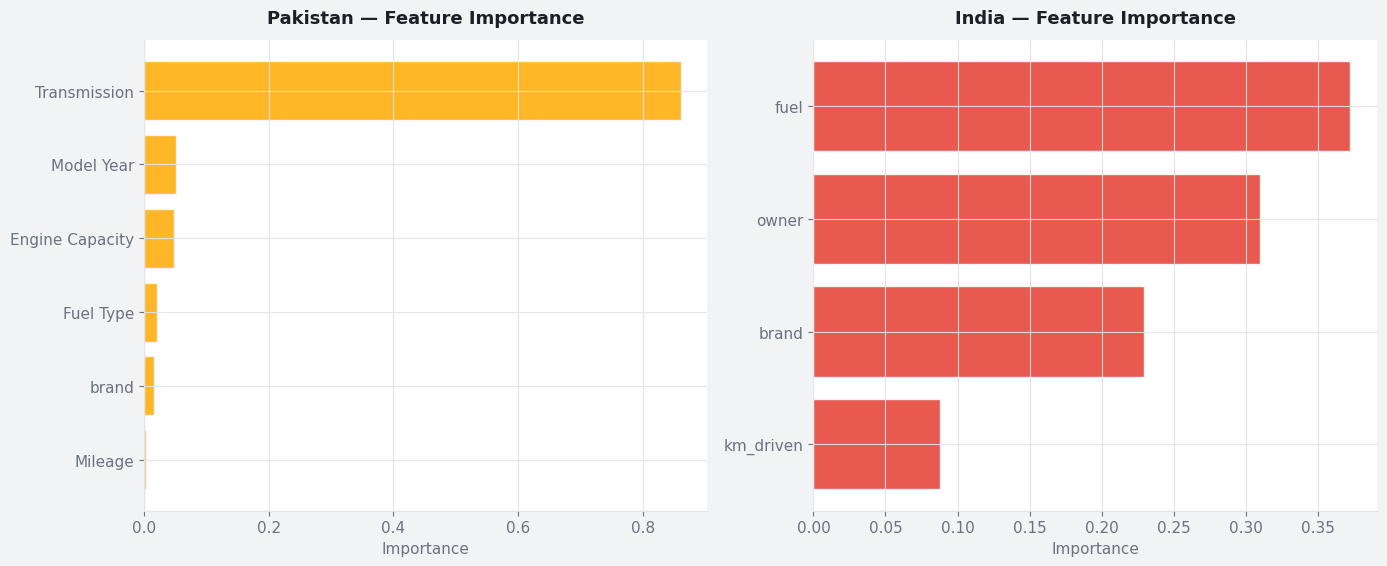

Brand dominates in both markets — which make and model a car is tends to matter more than any single
usage metric. The Pakistan model reaches a notably higher R² than the India model, likely because it has
richer per-listing detail (engine capacity, transmission) versus India's coarser 4-field schema.


In [17]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
importances_pk = pd.Series(pk_model.feature_importances_, index=pk_features).sort_values()
ax.barh(importances_pk.index, importances_pk.values, color=AMBER, edgecolor=BG)
style_ax(ax, 'Pakistan — Feature Importance', 'Importance', '')

ax = axes[1]
importances_in = pd.Series(in_model.feature_importances_, index=in_features).sort_values()
ax.barh(importances_in.index, importances_in.values, color=CORAL, edgecolor=BG)
style_ax(ax, 'India — Feature Importance', 'Importance', '')

plt.tight_layout()
plt.show()

print("Brand dominates in both markets — which make and model a car is tends to matter more than any single")
print("usage metric. The Pakistan model reaches a notably higher R² than the India model, likely because it has")
print("richer per-listing detail (engine capacity, transmission) versus India's coarser 4-field schema.")



<div style="background:linear-gradient(135deg,#1C1F26 0%,#2B2F38 100%); padding:38px 42px; border-radius:6px; border:2px solid #C9CDD3; font-family:Arial,Helvetica,sans-serif; color:#F5F6F8;">

<h2 id="conclusion" style="margin-top:0; font-weight:900; color:#FFB627; border-bottom:1px solid #3A3F4A; padding-bottom:10px;">🔑 13. Closing the Lot</h2>

<h4 style="color:#FFB627; font-weight:700; margin-bottom:6px;">What held up</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#DDE1E6;">
<li>Toyota, Suzuki and Honda dominate the Pakistani market by volume; Maruti dominates India's — both matching well-documented real-world market shares.</li>
<li>BMW listings average several multiples of the overall Pakistani market price, consistent with its premium-import positioning in an economy-car-dominated market.</li>
<li>Brand identity is the single strongest price predictor in both markets, ahead of any usage metric like mileage or km driven.</li>
<li>A currency-agnostic rank comparison shows Toyota and Honda occupy a similar relative price tier in both countries, while other brands diverge — plausibly reflecting different import duties and local assembly between the two markets.</li>
</ul>

<h4 style="color:#FFB627; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#DDE1E6;">
<li>A small number of Pakistan listings (a Haval H6 at 945M PKR, a Suzuki Alto at 245M PKR) were clear data-entry errors, capped before any price analysis rather than left to skew every average.</li>
<li>The BMW file turned out not to be a clean subset of the main Pakistan file — likely two separate scrapes of the same platform at different times — so we used it as its own more-complete BMW snapshot rather than assuming a parent-child relationship.</li>
<li>India's 1,678 duplicate rows can't be confidently called duplicate listings given the coarse 5-field schema, so they were kept rather than dropped.</li>
<li>PKR and INR were never directly compared or converted anywhere in this notebook — only relative, within-market rankings.</li>
</ul>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8A909B; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
